# Hands on with the Federalist Papers

Peter Ralph  
2026-02-04

# The Federalist Papers

## 

From the [Library of
Congress](https://guides.loc.gov/federalist-papers/full-text):

> The Federalist, commonly referred to as the Federalist Papers, is a
> series of 85 essays written by Alexander Hamilton, John Jay, and James
> Madison between October 1787 and May 1788. The essays were published
> anonymously, under the pen name “Publius,” in various New York state
> newspapers of the time.

## 

<figure>
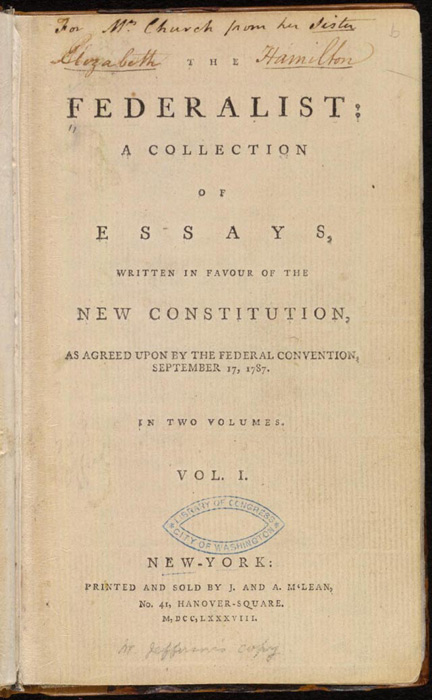
<figcaption aria-hidden="true">image of the cover</figcaption>
</figure>

*from Wikimedia*

## A mystery

Of 85 essays,

-   five were written by John Jay
-   three were written by Alexander Hamilton and James Madison together
-   15 were written by James Madison
-   51 were written by Alexander Hamilton
-   **but** three were claimed\* by both Madison and Hamilton

$^*$ in Hamilton’s case, in a list written two days before his death by
duel.

## Mosteller and Wallace (1963)

<figure>
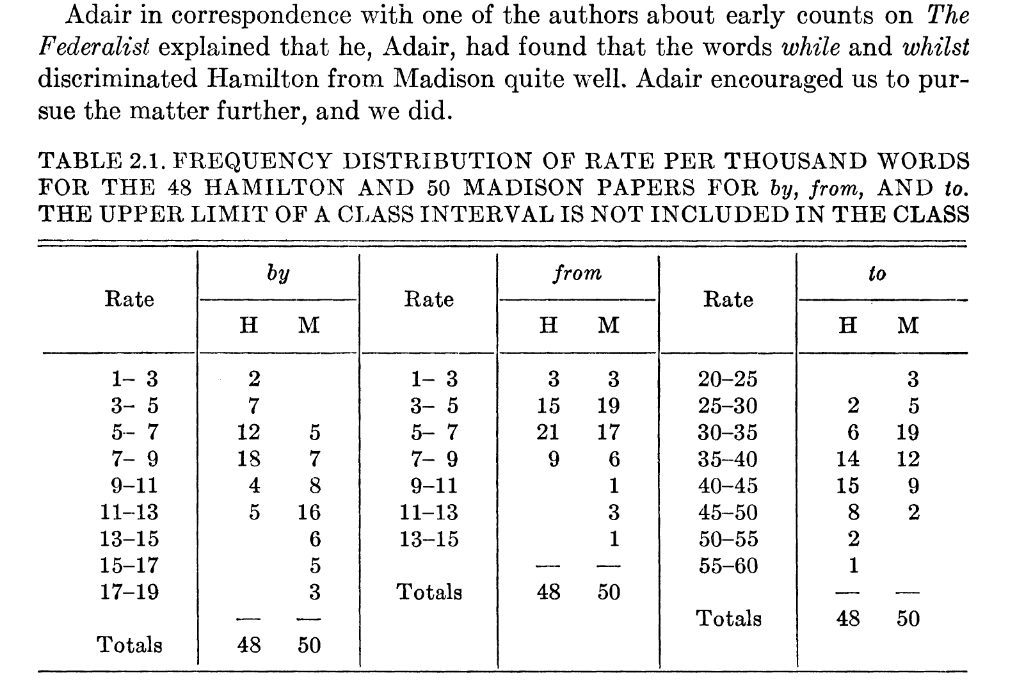
<figcaption aria-hidden="true">Table 2.1 of counts of ‘by’, ‘from’, and
‘to’, from Mosteller and Wallace</figcaption>
</figure>

## The results (roughly)

> Alexander joins forces with James Madison and John Jay To write a
> series of essays defending the new United States Constitution,
> entitled The Federalist Papers. The plan was to write a total of 25
> essays, the work Divided evenly among the three men. In the end, they
> wrote eighty-five essays in the span of six months. John Jay got sick
> after writing five James Madison wrote twenty-nine. Hamilton wrote the
> other fifty-one!

*Miranda, 2015*

## 

Mosteller and Wallace took a very hands-on and guided approach, counting
numbers of certain ‘filler’ words per block of 200 words:

> The words in an article were typed one word per line on a long paper
> tape, like adding machine tape. Then with scissors the tape was cut
> into slips, one word per slip . … When the counting was going on, if
> someone opened the door, slips of paper would fly about the room.

*Mosteller, 2010, quoted in [Text As
Data](https://press.princeton.edu/books/hardcover/9780691207544/text-as-data)*

## An exploratory approach

We’ll start with some exploration. A knee-jerk response to this question
(“who wrote these eleven papers”) might be: “hey let’s do dimension
reduction and see if the authors cluster”.

What do you think about this?

-   If the authors *do* cluster, why do you think this would happen?
    (i.e., where’s the signal for this coming from?)
-   If the authors *do* cluster, then does this give a good answer to
    the question?
-   Are there ways that this might mislead us?
-   What’s a more direct way you might answer the question?

# Let’s have a look

## set-up

In [1]:
import json, re
import pandas as pd
import numpy as np
import plotnine as p9
import scipy
import sklearn.decomposition, sklearn.manifold

## The data

You can get the data from this file:
[data/federalist.json](../data/federalist.json). It is a text file,
where each line is a JSON entry, containing: `author`, `text`, `date`,
`title`, `paper_id`, and `venue`.

In [4]:
with open("data/federalist.json", 'r') as f:
    text = [json.loads(line) for line in f]

info = pd.DataFrame(
    { k: [t[k] for t in text] for k in ['author', 'date', 'title', 'paper_id', 'venue']}
).assign(length = [len(t['text'].split(" ")) for t in text])
info

,author,date,title,paper_id,venue,length
0,HAMILTON,None,General Introduction,1,For the Independent Journal,1468
1,JAY,None,Concerning Dangers from Foreign Force and Infl...,2,For the Independent Journal,1513
2,JAY,None,The Same Subject Continued (Concerning Dangers...,3,For the Independent Journal,1310
3,JAY,None,The Same Subject Continued (Concerning Dangers...,4,For the Independent Journal,1480
4,JAY,None,The Same Subject Continued (Concerning Dangers...,5,For the Independent Journal,1214
...,...,...,...,...,...,...
80,HAMILTON,None,"The Judiciary Continued, and the Distribution ...",81,"From McLEAN's Edition, New York",3562
81,HAMILTON,None,The Judiciary Continued,82,"From McLEAN's Edition, New York",1409
82,HAMILTON,None,The Judiciary Continued in Relation to Trial b...,83,"From MCLEAN's Edition, New York",5306
83,HAMILTON,None,Certain General and Miscellaneous Objections t...,84,"From McLEAN's Edition, New York",3816


In [7]:
info['author'].value_counts(dropna=False)

author
HAMILTON                51
MADISON                 15
HAMILTON OR MADISON     11
JAY                      5
HAMILTON AND MADISON     3
Name: count, dtype: int64

In [8]:
info['venue'].value_counts(dropna=False)

venue
From the New York Packet           46
For the Independent Journal        25
From the Daily Advertiser           4
From McLEAN's Edition, New York     4
From MCLEAN's Edition, New York     3
For the Independent Fournal         1
From McLEAN'S Edition, New York     1
None                                1
Name: count, dtype: int64

## What’s the plan?

1.  look at, and clean the data
2.  do PCA on the word count matrix
3.  think about the results
4.  adjust how we’re doing the PCA and iterate

## Cleaning:

The [re.sub](https://docs.python.org/3/library/re.html#re.sub) function
will be useful.

In [9]:
def clean(t):
    return t

## Counting:

Once it’s cleaned, let’s count:

In [10]:
from collections import Counter

words = np.unique(" ".join([clean(t['text']) for t in text]).split(" "))

def tabwords(x, words):
    d = Counter(x.split(" "))
    out = np.array([d[w] for w in words])
    return out

wordmat = np.array([tabwords(clean(t['text']), words) for t in text])

In [11]:
words

array(['', '"', '"\n', ..., 'zealous', 'zealous\nadmirers',
       'zealous\npatrons'], shape=(27087,), dtype='<U33')

In [12]:
wordmat.shape, info.shape

((85, 27087), (85, 6))

## PCA

Let’s do it “by hand” with SVD:

In [13]:
x = wordmat

pcs, evals, evecs = scipy.sparse.linalg.svds(x, k=4)
eord = np.argsort(evals)[::-1]
evals = evals[eord]
evecs = evecs[eord,:]
pcs = pcs[:,eord]
pc_df = pd.concat([
    info,
    pd.DataFrame({f"PC{k+1}" : pcs[:,k] for k in range(pcs.shape[1])})
], axis=1)
loadings = pd.DataFrame(evecs.T, columns=[f"PC{k+1}" for k in range(pcs.shape[1])], index=words)

In [14]:
pc_df

,author,date,title,paper_id,venue,length,PC1,PC2,PC3,PC4
0,HAMILTON,None,General Introduction,1,For the Independent Journal,1468,-0.069033,-0.020443,0.037893,-0.016055
1,JAY,None,Concerning Dangers from Foreign Force and Infl...,2,For the Independent Journal,1513,-0.064319,0.050669,0.236909,-0.187730
2,JAY,None,The Same Subject Continued (Concerning Dangers...,3,For the Independent Journal,1310,-0.054326,0.013692,0.144542,-0.154849
3,JAY,None,The Same Subject Continued (Concerning Dangers...,4,For the Independent Journal,1480,-0.055798,0.011690,0.323187,-0.130395
4,JAY,None,The Same Subject Continued (Concerning Dangers...,5,For the Independent Journal,1214,-0.045703,-0.020623,0.221338,-0.117743
...,...,...,...,...,...,...,...,...,...,...
80,HAMILTON,None,"The Judiciary Continued, and the Distribution ...",81,"From McLEAN's Edition, New York",3562,-0.191658,-0.105728,-0.250344,-0.060608
81,HAMILTON,None,The Judiciary Continued,82,"From McLEAN's Edition, New York",1409,-0.077003,-0.001900,-0.082523,-0.032990
82,HAMILTON,None,The Judiciary Continued in Relation to Trial b...,83,"From MCLEAN's Edition, New York",5306,-0.259439,-0.514723,-0.221726,-0.322509
83,HAMILTON,None,Certain General and Miscellaneous Objections t...,84,"From McLEAN's Edition, New York",3816,-0.190469,-0.067131,-0.042777,0.109888


In [15]:
loadings

,PC1,PC2,PC3,PC4
,-0.005333,0.052254,0.005154,-0.002772
"""",-0.000627,0.010148,-0.005017,0.003891
"""\n",-0.000029,0.000039,0.000671,0.000459
"""7.",-0.000071,0.000643,-0.000258,0.001065
"""A",-0.000045,-0.000369,0.000213,0.000346
...,...,...,...,...
"zeal,",-0.000081,0.000464,0.002000,-0.002658
"zeal,\nthan",-0.000057,0.001310,-0.000462,-0.000415
zealous,-0.000149,-0.000620,-0.000754,0.000290
zealous\nadmirers,-0.000033,-0.000255,-0.000562,0.000054


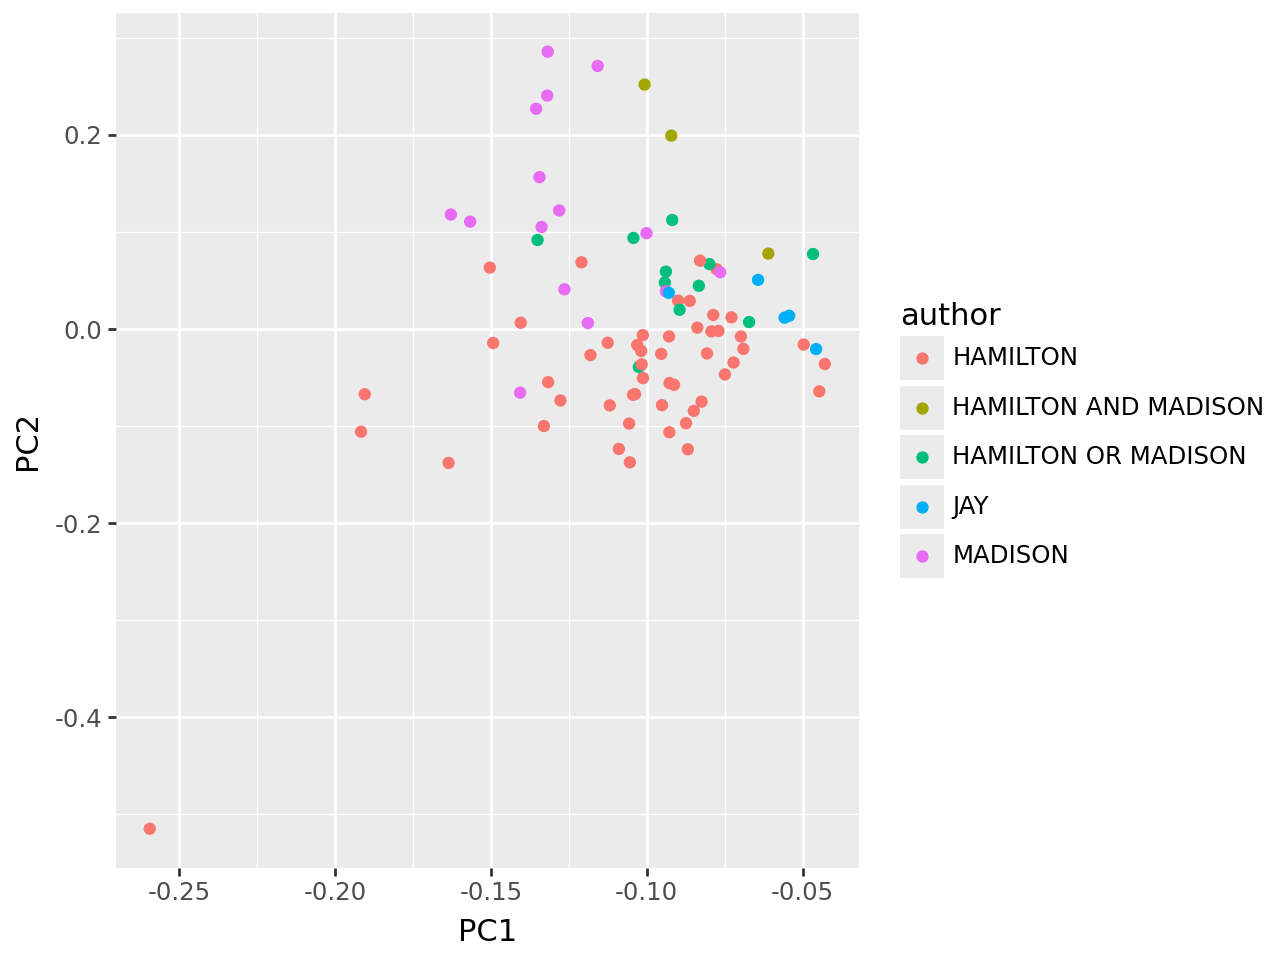

In [16]:
(
    pc_df
    >>
    p9.ggplot(p9.aes(x="PC1", y="PC2", color="author"))
    + p9.geom_point()
)

# Part 2: With data cleaning

In [52]:
def clean(t):
    t = re.sub("[\n\t]", " ", t).lower()
    t = re.sub("  *", " ", t)
    t = re.sub("[^a-z ]", "", t)
    t = t.strip()
    return t

In [40]:
re.sub("[^a-z ]", "", re.sub("  *", " ", text[0]['text'].replace("\n", " ").lower()))[:500]

'to the people of the state of new york after an unequivocal experience of the inefficacy of the subsisting federal government you are called upon to deliberate on a new constitution for the united states of america the subject speaks its own importance comprehending in its consequences nothing less than the existence of the union the safety and welfare of the parts of which it is composed the fate of an empire in many respects the most interesting in the world it has been frequently remarked tha'

In [53]:
clean(text[0]['text']).split(" ")[:10]

['to', 'the', 'people', 'of', 'the', 'state', 'of', 'new', 'york', 'after']

## Counting:

Once it’s cleaned, let’s count:

In [54]:
from collections import Counter

# the first word is "empty string" for some reason; we drop it
words = np.unique(" ".join([clean(t['text']) for t in text]).split(" "))[1:]

def tabwords(x, words):
    d = Counter(x.split(" "))
    out = np.array([d[w] for w in words])
    return out

wordmat = np.array([tabwords(clean(t['text']), words) for t in text])

In [55]:
words

array(['a', 'abandon', 'abandoned', ..., 'zeal', 'zealand', 'zealous'],
      shape=(8715,), dtype='<U20')

In [56]:
wordmat.shape, info.shape

((85, 8715), (85, 6))

## PCA

Let’s do it “by hand” with SVD:

In [57]:
x = wordmat

pcs, evals, evecs = scipy.sparse.linalg.svds(x, k=4)
eord = np.argsort(evals)[::-1]
evals = evals[eord]
evecs = evecs[eord,:]
pcs = pcs[:,eord]
pc_df = pd.concat([
    info,
    pd.DataFrame({f"PC{k+1}" : pcs[:,k] for k in range(pcs.shape[1])})
], axis=1)
loadings = pd.DataFrame(evecs.T, columns=[f"PC{k+1}" for k in range(pcs.shape[1])], index=words)

In [15]:
loadings

,PC1,PC2,PC3,PC4
,-0.005333,0.052254,0.005154,-0.002772
"""",-0.000627,0.010148,-0.005017,0.003891
"""\n",-0.000029,0.000039,0.000671,0.000459
"""7.",-0.000071,0.000643,-0.000258,0.001065
"""A",-0.000045,-0.000369,0.000213,0.000346
...,...,...,...,...
"zeal,",-0.000081,0.000464,0.002000,-0.002658
"zeal,\nthan",-0.000057,0.001310,-0.000462,-0.000415
zealous,-0.000149,-0.000620,-0.000754,0.000290
zealous\nadmirers,-0.000033,-0.000255,-0.000562,0.000054


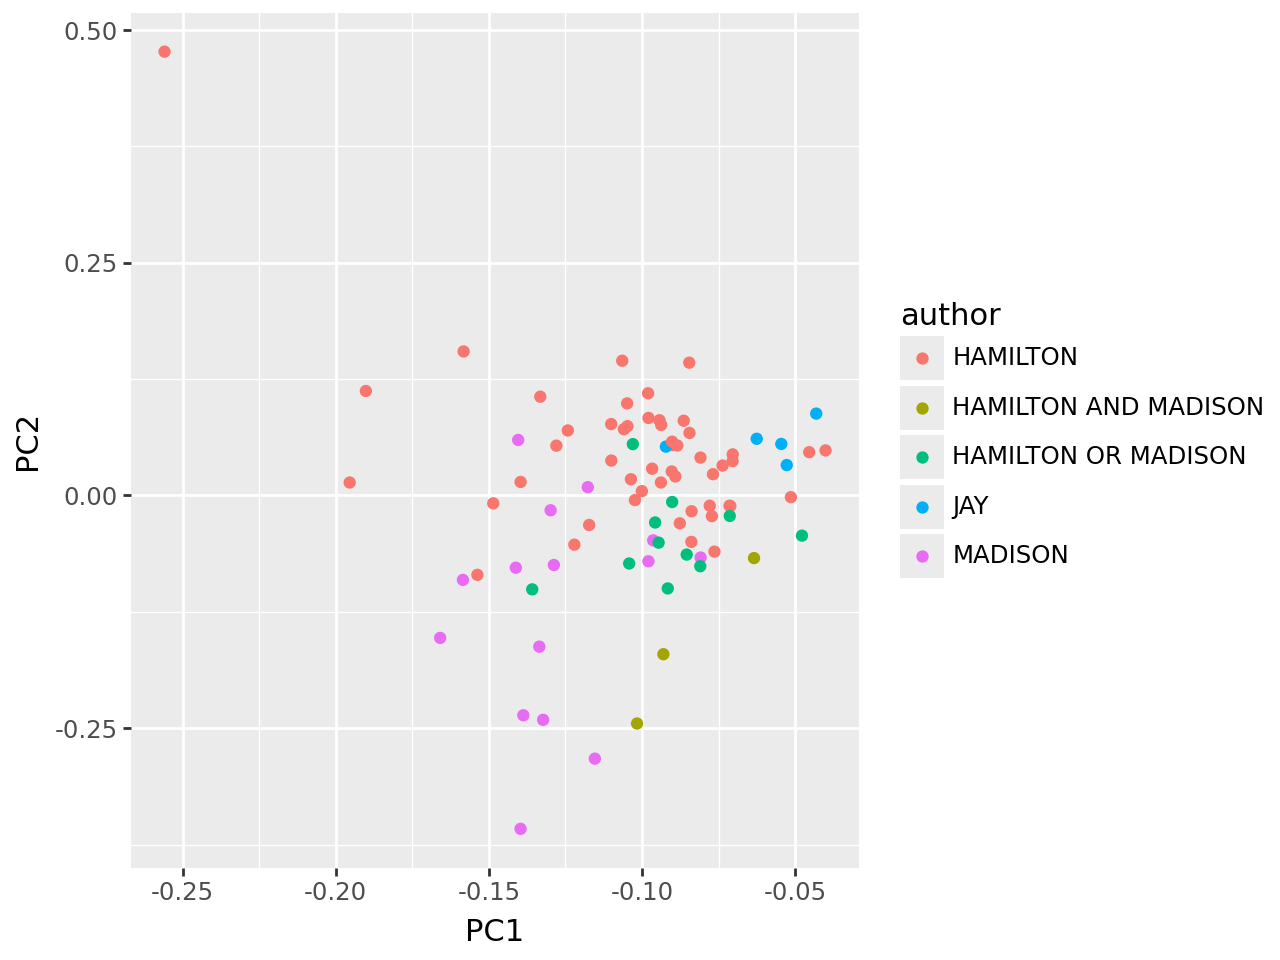

In [58]:
(
    pc_df
    >>
    p9.ggplot(p9.aes(x="PC1", y="PC2", color="author"))
    + p9.geom_point()
)

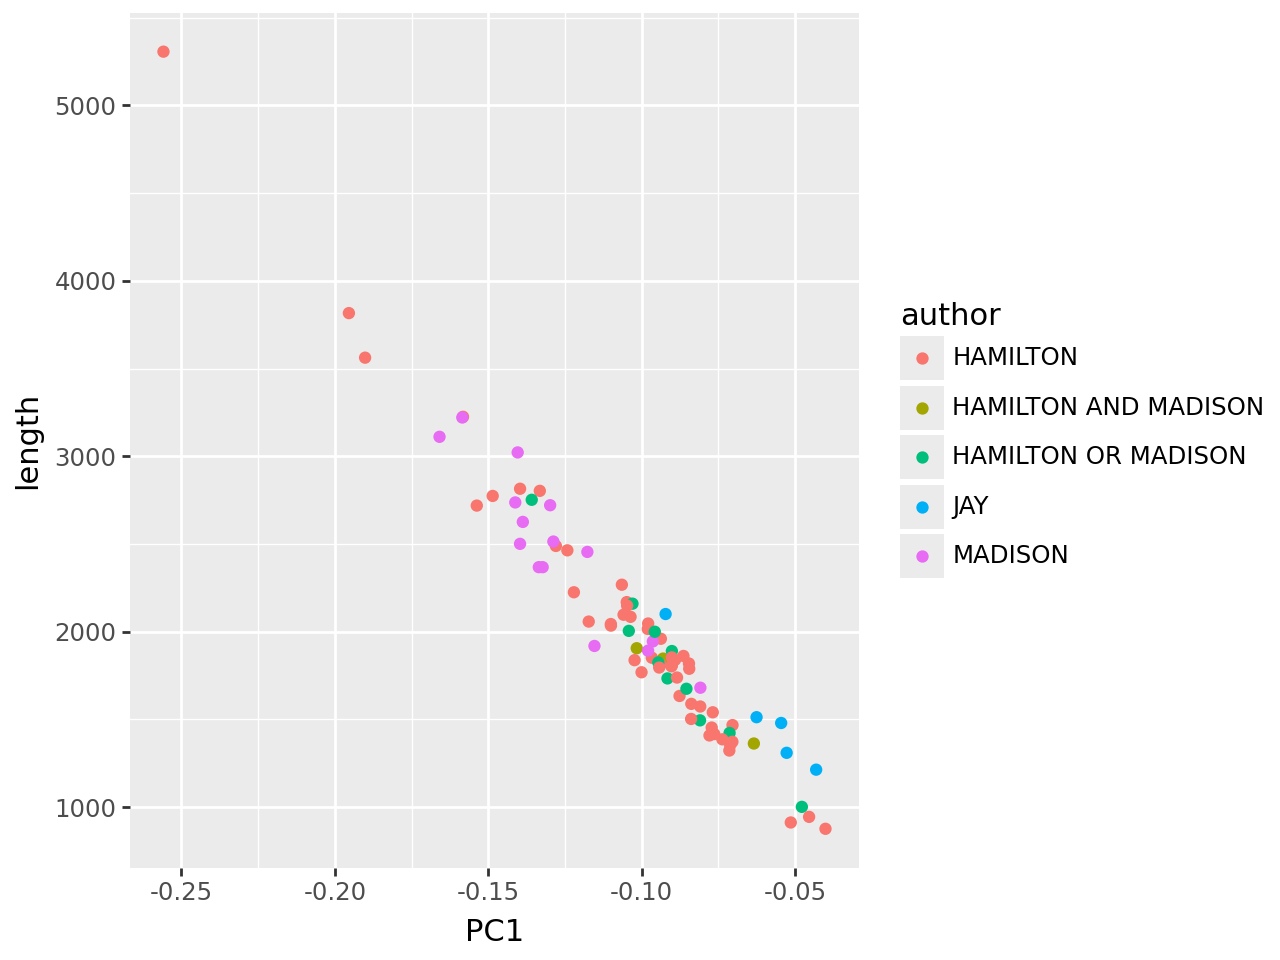

In [59]:
(
    pc_df
    >>
    p9.ggplot(p9.aes(x="PC1", y="length", color="author"))
    + p9.geom_point()
)

# Normalization

Turns out PC1 was just "length":
(almost?) all loadings were negative.
So, let's switch to using *proportion* of words in the essay
instead of *number* of words in the essay.

In [67]:
np.sum(wordmat, axis=1)

array([1615, 1671, 1447, 1636, 1346, 2028, 2305, 2058, 1993, 3004, 2503,
       2162,  967, 2146, 3088, 2042, 1572, 2112, 2049, 1520, 2001, 3552,
       1805, 2007, 1991, 2385, 1456, 1605, 2239, 1972, 1738, 1492, 1694,
       2219, 2258, 2741, 2719, 3325, 2614, 3026, 3550, 2784, 3432, 2900,
       2125, 2620, 2745, 1864, 1653, 1109, 1921, 1851, 2171, 2005, 2044,
       1573, 2213, 2090, 1917, 2252, 1525, 2391, 3043, 2315, 2024, 2268,
       1654, 1509, 2981, 3111, 1748, 2044, 2369, 1005, 1948, 2306, 1979,
       3061, 1037, 2460, 3915, 1547, 5838, 4179, 2710])

In [68]:
x = wordmat / np.sum(wordmat, axis=1)[:, np.newaxis]

pcs, evals, evecs = scipy.sparse.linalg.svds(x, k=4)
eord = np.argsort(evals)[::-1]
evals = evals[eord]
evecs = evecs[eord,:]
pcs = pcs[:,eord]
pc_df = pd.concat([
    info,
    pd.DataFrame({f"PC{k+1}" : pcs[:,k] for k in range(pcs.shape[1])})
], axis=1)
loadings = pd.DataFrame(evecs.T, columns=[f"PC{k+1}" for k in range(pcs.shape[1])], index=words)

In [69]:
loadings

,PC1,PC2,PC3,PC4
a,0.154668,0.063259,0.265856,-0.229460
abandon,0.000198,0.000078,0.000107,0.000010
abandoned,0.000126,-0.000057,0.000920,0.000332
abandoning,0.000027,0.000144,0.000174,-0.000405
abate,0.000032,0.000033,0.000187,-0.000290
...,...,...,...,...
yourselves,0.000046,0.003017,-0.000964,0.000324
zaleucus,0.000024,0.000161,-0.000039,-0.000185
zeal,0.000972,0.002815,-0.002387,0.002766
zealand,0.000052,0.000033,-0.001470,-0.001132


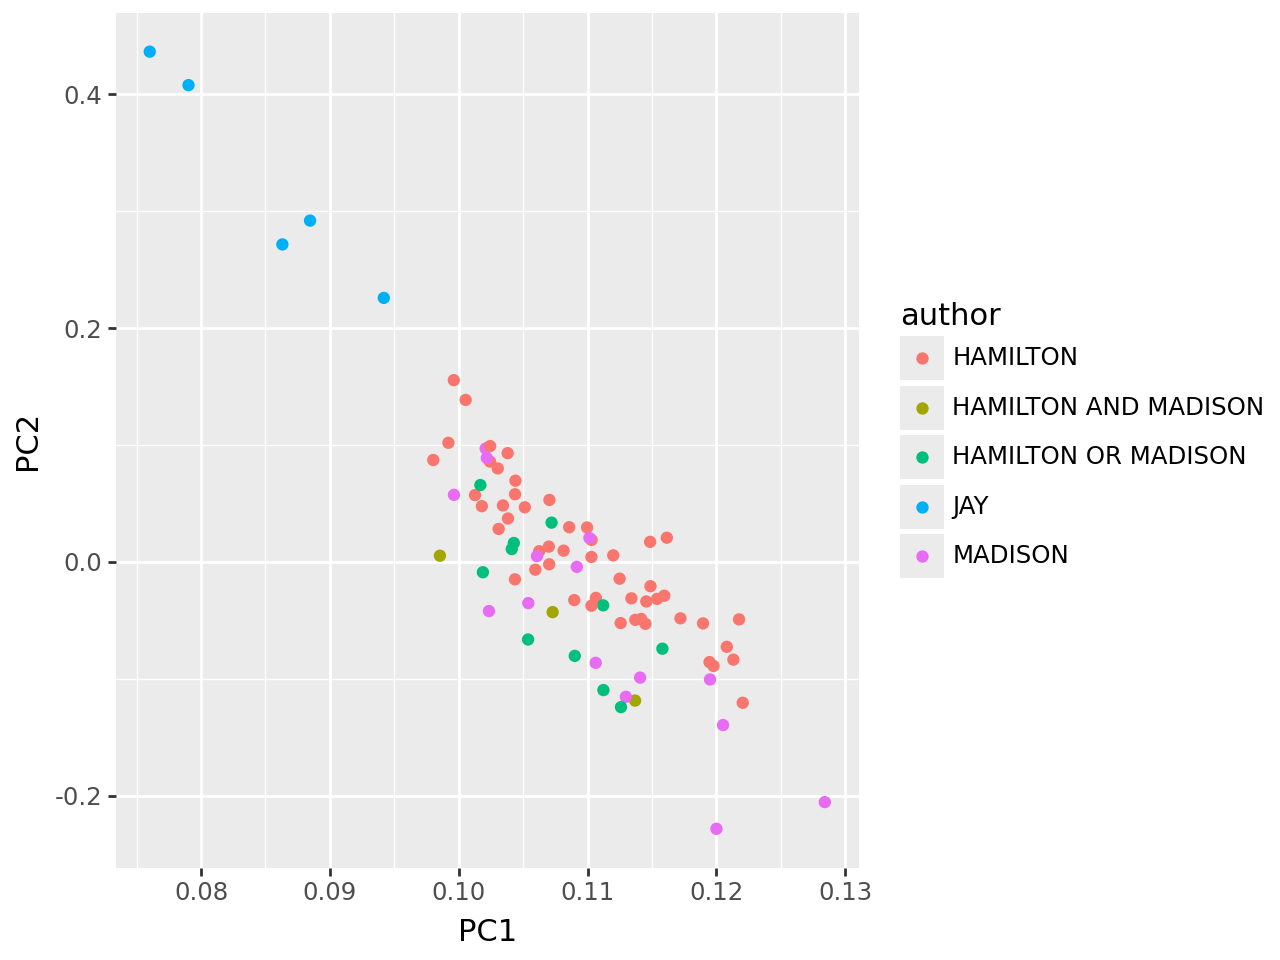

In [70]:
(
    pc_df
    >>
    p9.ggplot(p9.aes(x="PC1", y="PC2", color="author"))
    + p9.geom_point()
)

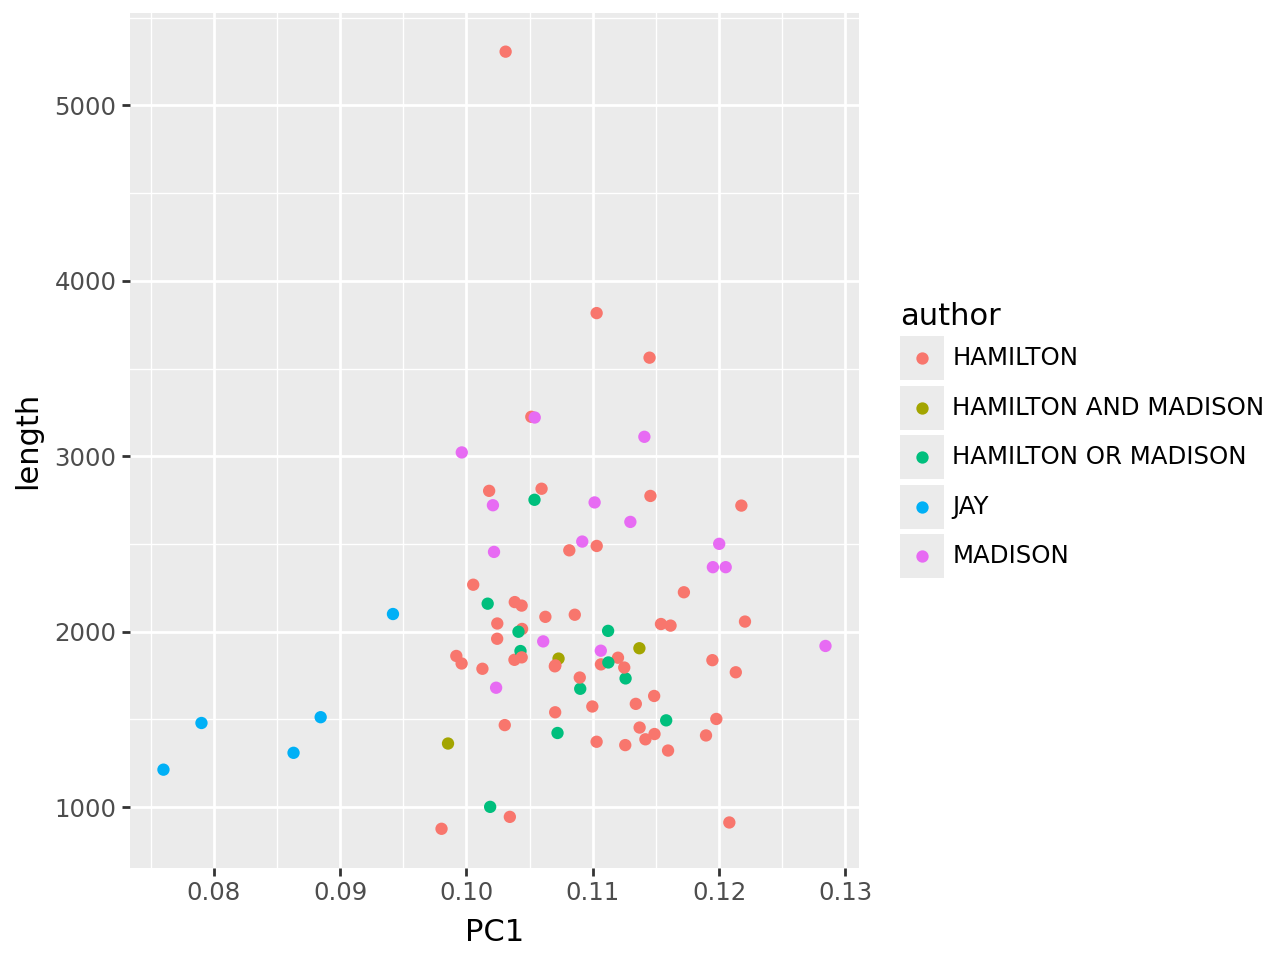

In [71]:
(
    pc_df
    >>
    p9.ggplot(p9.aes(x="PC1", y="length", color="author"))
    + p9.geom_point()
)

## what's different about Jay?

these are words that are associated with Jay

In [74]:
loadings.sort_values("PC1").head(n=30)

,PC1,PC2,PC3,PC4
quadrate,0.000014,0.000045,0.000183,0.00002
accessible,0.000014,0.000045,0.000183,0.00002
wilful,0.000014,0.000045,0.000183,0.00002
surmount,0.000014,0.000045,0.000183,0.00002
senseless,0.000014,0.000045,0.000183,0.00002
indispose,0.000014,0.000045,0.000183,0.00002
obliging,0.000014,0.000045,0.000183,0.00002
canon,0.000014,0.000045,0.000183,0.00002
explore,0.000014,0.000045,0.000183,0.00002
misapprehensions,0.000014,0.000045,0.000183,0.00002


and these are *not*

In [75]:
loadings.sort_values("PC1").tail(n=30)

,PC1,PC2,PC3,PC4
may,0.031706,0.017920,0.036224,0.081347
states,0.032364,-0.035431,-0.007890,-0.017861
government,0.032737,0.017675,-0.051085,0.138948
they,0.035837,0.126724,-0.051232,0.023311
an,0.036602,0.002410,0.086499,-0.048685
on,0.036625,-0.017005,-0.143751,0.049852
are,0.039543,0.056151,-0.048076,0.036129
from,0.041182,0.069344,-0.006991,-0.001865
with,0.041636,0.057788,-0.042652,-0.047109
their,0.043492,0.130353,-0.110207,0.036838


*tentative conclusion:* looks like maybe Jay uses less small words?

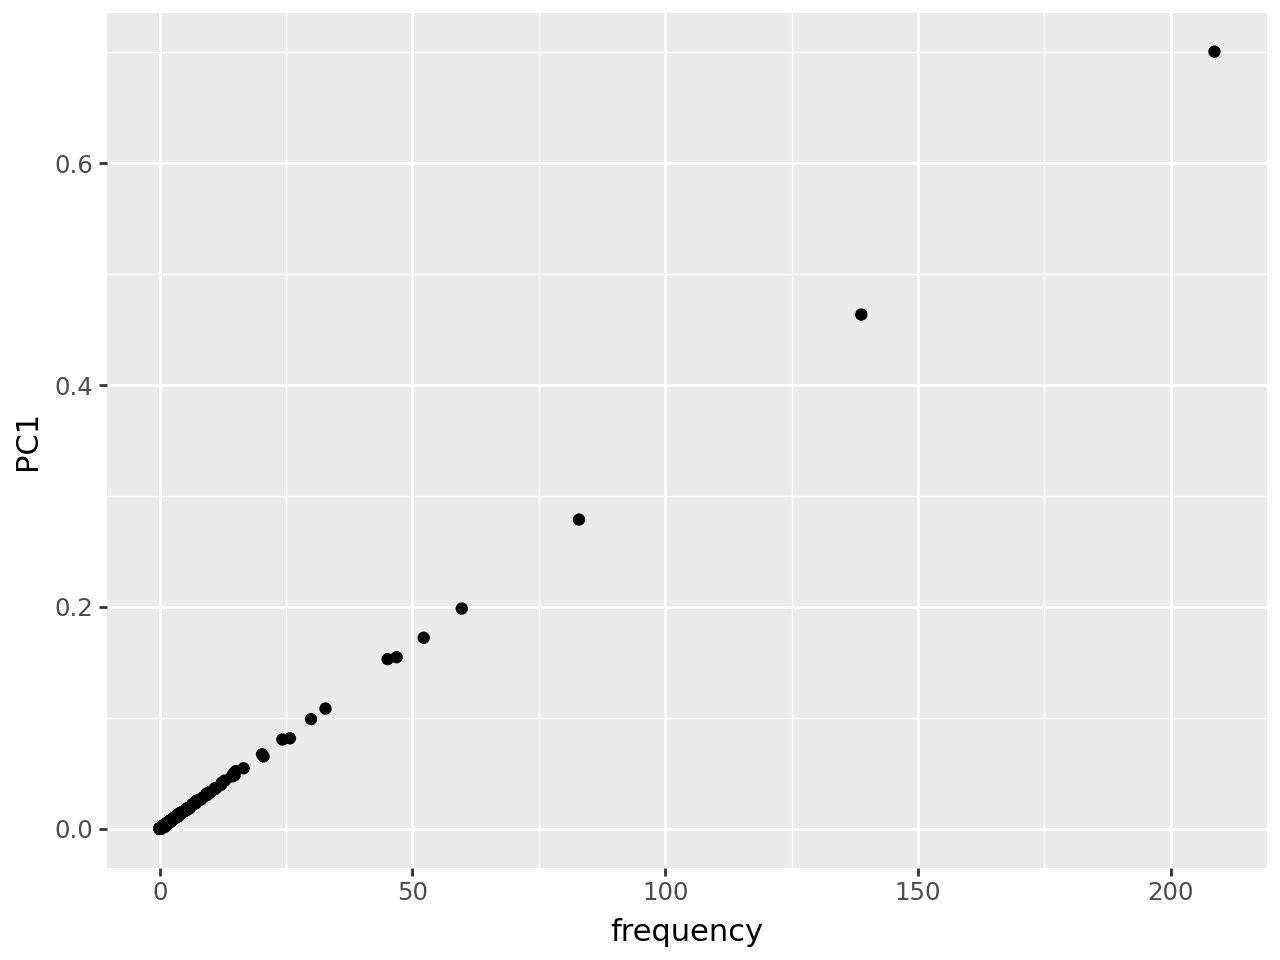

In [80]:
loadings['frequency'] = wordmat.mean(axis=0)

p9.ggplot(loadings, p9.aes(x='frequency', y='PC1')) + p9.geom_point()